In [20]:
import os
import subprocess
import tempfile
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [21]:
dataset_dir = "/Users/alejandroconesa/Documents/Carrera/practicas/msmd/msmd_aug_v1-1_no-audio/"
print(os.path.exists(dataset_dir))

True


In [22]:
resultado = subprocess.run(["fluidsynth", "-ni", "-F", "../data/ejemplos/prueba1.wav", "-r", "44100", "../data/soundfonts/FluidR3_GM.sf2", dataset_dir+"BachJS__BWVAnh131__air/performances/BachJS__BWVAnh131__air_tempo-900_ElectricPiano/BachJS__BWVAnh131__air_tempo-900_ElectricPiano.midi"], text=True, capture_output=True)

print(resultado.returncode)
print(resultado.stdout)
print(resultado.stderr)

0
FluidSynth runtime version 2.6.0
Copyright (C) 2000-2026 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '../data/ejemplos/prueba1.wav'..




## Sintetizar audio .midi -> .wav

In [23]:
INSTRUMENTS = [
    {"tag": "acoustic_piano_imis_1",   "soundfont": "../data/soundfonts/acoustic_grand_piano.sf2", "banco": 0, "programa": 0},
    {"tag": "YamahaGrandPiano",  "soundfont": "../data/soundfonts/FluidR3_GM.sf2",            "banco": 0, "programa": 0},
    {"tag": "ElectricPiano",     "soundfont": "../data/soundfonts/FluidR3_GM.sf2",            "banco": 0, "programa": 2},
]

SOUNDFONTS = ["../data/soundfonts/FluidR3_GM.sf2", "../data/soundfonts/acoustic_grand_piano.sf2"]

def resolver_instrumento(nombre_archivo):
    for inst in INSTRUMENTS:
        if inst["tag"] in nombre_archivo:
            return inst
    return None

def construir_select(instrumento):
    sfid = SOUNDFONTS.index(instrumento["soundfont"]) + 1  # 1-based, orden de carga
    lineas = [f"select {canal} {sfid} {instrumento['banco']} {instrumento['programa']}"
              for canal in range(16)]
    return "\n".join(lineas) + "\n"

In [24]:
max_iter_counter = 10
iter_counter = 0
limiter = True
pieces = os.listdir(dataset_dir)

for piece in pieces:
    if iter_counter >= max_iter_counter and limiter:
        break

    if piece == ".DS_Store":
        continue

    performances = [perf for perf in os.listdir(dataset_dir + piece + "/performances") if "grand-piano-YDP" not in perf]

    if len(performances) == 0:
        continue

    performance_name = performances[0]
    performances_files = os.listdir(dataset_dir + piece + "/performances/" + performance_name)

    for perf_file in performances_files:
        if perf_file != "features":
            midi_file = perf_file

    instrumento = resolver_instrumento(performance_name)
    if instrumento is None:
        print(f"[SKIP] {performance_name}: ninguna etiqueta coincide")
        continue
    
    # la parte del select y los mensajes skip fail y ok son aportación de claude
    contenido_select = construir_select(instrumento)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False, prefix="select_")
    tmp.write(contenido_select)
    tmp.close()

    args = [
        "fluidsynth",
        "-ni",
        "-F", "./wavs/" + performance_name + ".wav",
        "-r", "44100",
        "-f", tmp.name,
    ] + SOUNDFONTS + [
        dataset_dir + piece + "/performances/" + performance_name + "/" + midi_file
    ]

    resultado = subprocess.run(args, text=True, capture_output=True)
    os.unlink(tmp.name)

    if resultado.returncode != 0:
        print(f"[FAIL] {performance_name}: {resultado.stderr[-300:]}")
    else:
        print(f"[OK] {performance_name}")
    iter_counter += 1

[OK] CzernyC__Op_821__Czerny_Op_821_No_017_tempo-1000_ElectricPiano
[OK] MozartWA__KV331__KV331_1_2_var1_tempo-1100_ElectricPiano
[OK] RachmaninoffS__O23__rach-prelude23-06_tempo-1000_ElectricPiano
[OK] Traditional__traditioner_af_swenska_folk_dansar.1.16__traditioner_af_swenska_folk_dansar.1.16_tempo-1100_acoustic_piano_imis_1
[OK] JoplinS__TheStrenuousLife__TheStrenuousLife_tempo-950_acoustic_piano_imis_1
[OK] RachmaninoffS__O23__rach-prelude23-01_tempo-950_acoustic_piano_imis_1
[OK] HandelGF__Aylesford__06-impertinence_tempo-900_acoustic_piano_imis_1
[OK] BeethovenLv__O10__LVB_Sonate_10no1_3_tempo-900_YamahaGrandPiano
[OK] HandelGF__Aylesford__15-menuetii_tempo-1000_ElectricPiano
[OK] MussorgskyM__pictures-at-an-exhibition__promenade-1_tempo-1100_acoustic_piano_imis_1


## Espectrogramas

(128, 3280)


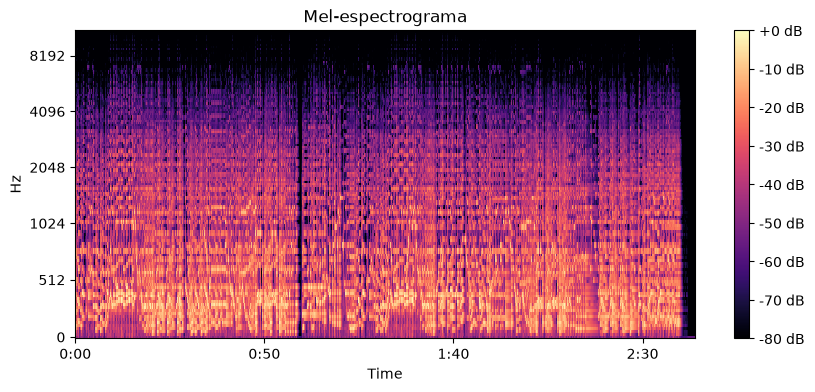

In [25]:
y, sr = librosa.load("../data/wavs/BeethovenLv__O10__LVB_Sonate_10no1_3_tempo-900_YamahaGrandPiano.wav", sr=22050)  # carga el audio

mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=1102)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print(mel_spec_db.shape)

fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=1102, x_axis="time", y_axis="mel", ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.set_title("Mel-espectrograma")

fig.savefig("../data/ejemplos/espectrograma.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/nt/lf6v74yn7d35rhdk44fjzkg00000gn/T/ipykernel_24193/3996649836.py:2: UserWarning: power_to_db was called on complex input so phase information will be discarded. To suppress this warning, call power_to_db(np.abs(D)**2) instead.
  stft_spectrogram_db = librosa.power_to_db(stft_spectrogram, ref=np.max)


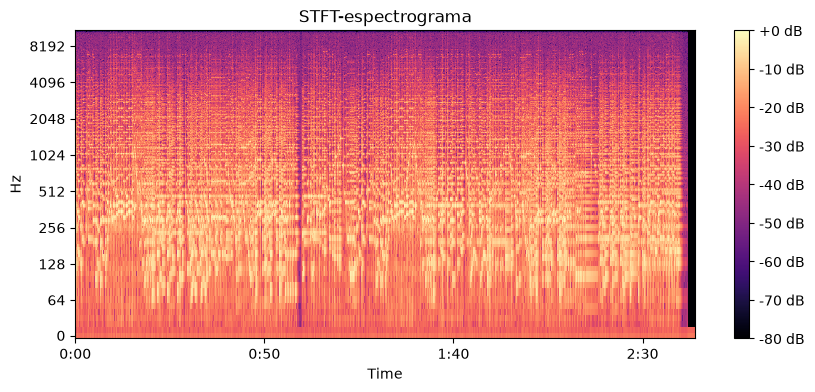

In [26]:
stft_spectrogram = librosa.stft(y=y, n_fft=2048, hop_length=1102)
stft_spectrogram_db = librosa.power_to_db(stft_spectrogram, ref=np.max)

fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(stft_spectrogram_db, sr=sr, hop_length=1102, x_axis="time", y_axis="log", ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.set_title("STFT-espectrograma")

fig.savefig("../data/ejemplos/espectrograma_stft.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [27]:
sr = 22050
n_fft = 2048
hop_length = 1102 
fmin = 60.0
fmax = 6000.0
num_bands = 78

def create_log_filterbank(sr, n_fft, fmin, fmax, num_bands):
    fft_freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    log_freqs = np.logspace(np.log10(fmin), np.log10(fmax), num_bands + 2)
    weights = np.zeros((num_bands, len(fft_freqs)))
    
    for i in range(num_bands):
        f_left = log_freqs[i]
        f_center = log_freqs[i + 1]
        f_right = log_freqs[i + 2]

        up = (fft_freqs - f_left) / (f_center - f_left)
        down = (f_right - fft_freqs) / (f_right - f_center)
        
        tri = np.maximum(0, np.minimum(up, down))
        weights[i, :] = tri

    return weights, log_freqs[1:-1]


stft_magnitude = np.abs(stft_spectrogram)

filterbank, bin_centers = create_log_filterbank(sr, n_fft, fmin, fmax, num_bands)
log_spectrogram = np.matmul(filterbank, stft_magnitude)
print(f"Forma del espectrograma filtrado: {log_spectrogram.shape}")


Forma del espectrograma filtrado: (78, 3280)


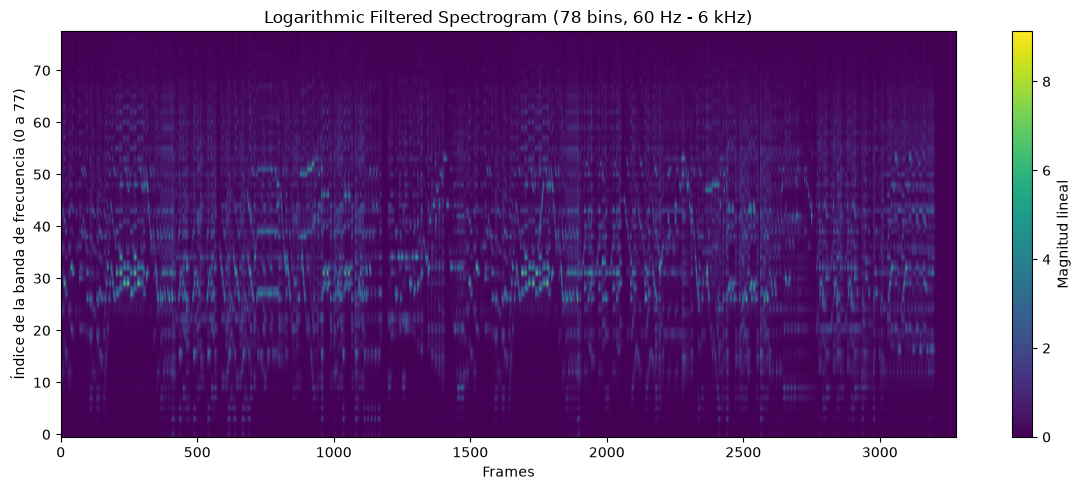

In [28]:
plt.figure(figsize=(12, 5))

img = plt.imshow(log_spectrogram, aspect='auto', origin='lower', cmap='viridis')

plt.title('Logarithmic Filtered Spectrogram (78 bins, 60 Hz - 6 kHz)')
plt.xlabel('Frames')
plt.ylabel('Índice de la banda de frecuencia (0 a 77)')
plt.colorbar(img, label='Magnitud lineal')
plt.tight_layout()
plt.show()

In [29]:
normalizado = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
imagen_uint8 = (normalizado * 255).astype(np.uint8)
imagen_uint8 = np.flipud(imagen_uint8)

Image.fromarray(imagen_uint8).save("../data/ejemplos/cnn_espectrograma.png")

In [30]:
for wav in os.listdir("../data/wavs"):
    name = wav[:-4]
    y, sr = librosa.load("../data/wavs/"+wav, sr=22050)  # carga el audio
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=1102)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    normalizado = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
    imagen_uint8 = (normalizado * 255).astype(np.uint8)
    imagen_uint8 = np.flipud(imagen_uint8)

    Image.fromarray(imagen_uint8).save(f"../data/spectrograms/{wav}.png")


## Imágenes

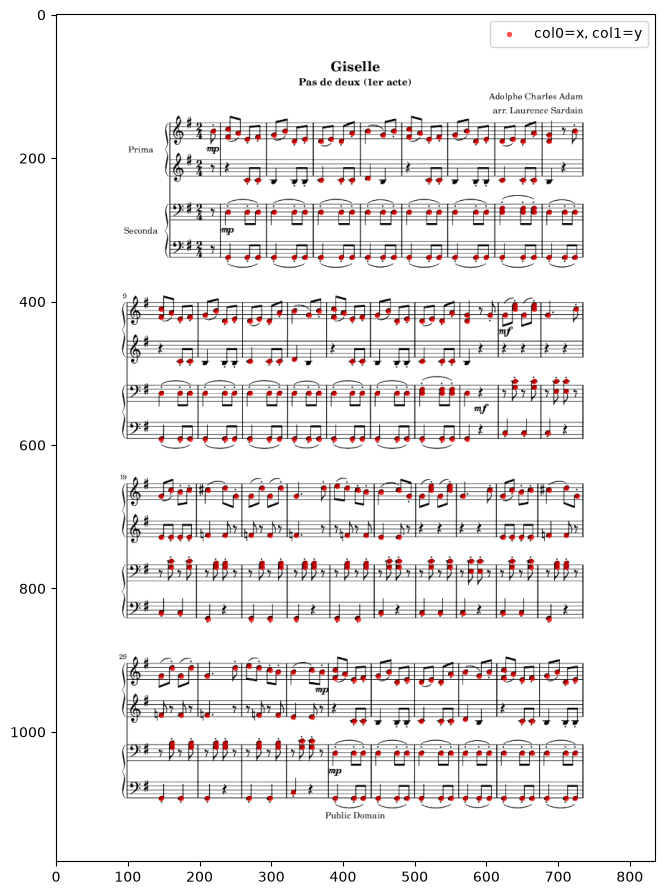

In [31]:
arr = np.load("/Users/alejandroconesa/Documents/Carrera/practicas/msmd/msmd_aug_v1-1_no-audio/AdamA__giselle__giselle/scores/AdamA__giselle__giselle_ly/coords/notes_01.npy", allow_pickle=True)
img = Image.open("/Users/alejandroconesa/Documents/Carrera/practicas/msmd/msmd_aug_v1-1_no-audio/AdamA__giselle__giselle/scores/AdamA__giselle__giselle_ly/img/01.png")
fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(img)

ax.scatter(arr[:, 1], arr[:, 0], c="red", s=8, alpha=0.6, label="col0=x, col1=y")

ax.legend()
plt.savefig("../data/ejemplos/check_overlay.png", dpi=100, bbox_inches="tight")
plt.show()

uv run construir_alineacion.py /Users/alexconesa/Documents/Carrera/practicas/msmd/msmd_aug_v1-1_no-audio/AdamA__giselle__giselle/scores/AdamA__giselle__giselle_ly

uv run construir_alineacion.py /Users/alexconesa/Documents/Carrera/practicas/msmd/msmd_aug_v1-1_no-audio/AdamA__giselle__giselle AdamA__giselle__giselle_tempo-1000_ElectricPiano